In [1]:
'''
Use Tally to check for downstream packet loss. This code is not able to detect local
packet loss. This script was written to read 1 data file of packets recorded from a run
where multiple tiles were enabled during QC testing for the v3a chip. The data file 
must have been run from a configuration where tally was enabled
'''

###############################
# Imports
###############################

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from matplotlib.ticker import PercentFormatter, FixedFormatter, FixedLocator

###############################
# Initialize
###############################

#filename = "/data/v3/FSDCube/Feb2026/cold_processed/scan/lt_prc8/convert_to_packet/binary-cosmics-2026_02_27_17_17_31_PST.hdf5"

# cold test of set 3, 9 tiles
filename = "/data/v3/10x16/20260505_set3_10_tiles/data/cold/packet-cold_ped_set3_9tiles_240s_220vref_no_hotchan_1.hdf5"

filename = "/data/v3/10x16/20260512_set4_10_tiles/data/cold/packet-cold_ped_set4_10tiles_240s_no_hotchan_links_disabled.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7,8,9,10]

# serial numbers for set 1 of tiles 1-10
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101', '4K00277', '4K03329', '4K04087' ]

# serial numbers for sets 2 and 3 
if "set2" in filename:
    chip_serial_number_list = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ]
elif "set3" in filename:
    chip_serial_number_list = ['', '4k00952', '4k03591', '4k03936', '4k00607', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]
elif "set4" in filename:
    chip_serial_number_list = ['', '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]    

# verbose = True will print out a detailed listing of the skipped tally counts for all chips 
verbose = False

# you can choose a particular chip to get more detailed information
verbose_tile = 1
verbose_chip = 16

# records tally by chip
tally = [[] for chp in range(256)]

# initialize variables
first_tile = True
unique_io_channels = []

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
                     ]
    
    return io_ch_per_tile[tile]

In [3]:
def get_data(filename):
    
    global unique_chips, tally, receipt_ts, bad_chip_count, missing, pkt_count, first_tile, unique_io_channels
    global tiles, chip_serial_number_list, highest_ts, chips_w_duplicates
    
    # initialize at tile level
    npkts = 0
    first_problem_chip = True
    
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]

    # determine the time period for this data file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)

    # mask for sync packets (type 6) and external trigger (type 83)
    sync_mask = (packets['packet_type'] == 6) & (packets['trigger_type'] == 83)
    nsyncs = len(packets[sync_mask]) 

    if first_tile:

        first_tile = False
        
        # plot receipt timestamps before applying rollover
        data_mask     = packets['packet_type']  == 1
        data_pkts_before_rollover   = packets[data_mask]
    
#################################################################################################
# create a consistently increasing counting sequence from a saw-toothed series of 
# pacman counts (the "receipt_timestamp")
#################################################################################################

        # rollover will be used to adapt the saw-toothed time series to a consistently-increasing 
        # time series. Begin by creating an array of zeros the length of packets
        rollover = np.zeros((len(packets),), dtype='i8')
            
        # rollover_ticks is an array of the same size as rollover, but holds the value of the 
        # number of ticks in each pacman clock cycle (1E7)
        rollover_ticks = rollover + 1E7
    
        # mask for the sync signal (packet type 6) that's externally generated (trigger_type 83) 
        # to reset the pacman clock and set those elements of rollover to 1E7
        mask = (packets['packet_type'] == 6) & (packets['trigger_type'] == 83)
        rollover[mask] = rollover_ticks[mask]
            
        # Use cumsum to asign the value of 1E7 to each element of rollover, incrementing that 
        # amount by an additional 1E7 at each subsequent sync point
        rollover = np.cumsum(rollover)
            
        # add rollover to each packet's receipt_timestamp to create a consistently-increasing
        # clock sequence for this file
        ts = packets['receipt_timestamp'].astype('i8') + rollover
        pk_ts = packets['timestamp'].astype('i8') + rollover
    
        # sort the counting sequence and the packets by the "rolled over" receipt timestamp
        sorted_idcs = np.argsort(ts)
        sorted_ts = ts[sorted_idcs]
        sorted_pk_ts = pk_ts[sorted_idcs]
        sorted_pkts = packets[sorted_idcs]
        
        # create arrays of sorted data packets
        data_mask     = sorted_pkts['packet_type']  == 1
        data_pkts     = sorted_pkts[data_mask]
        receipt_ts    = sorted_ts[data_mask]
        pk_ts         = sorted_pk_ts[data_mask]
        npkts         = len(data_pkts)   
        
        print(f"{npkts:,} data packets were collected over {livetime} seconds (average data rate = {npkts/livetime:,.0f} pkts/s)")
    
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.set_title(f'Receipt Timestamp after Rollover (with {nsyncs} sync pkts)\nBenchtop test v3a 10x16 tiles')
        ax.plot(receipt_ts)
        ax.set_xlabel("packet")
        ax.set_ylabel("Receipt Timestamp")  
        plt.show

    for tile in tiles:
    
        print(f"\n\n############################ Checking Tile {tile} ###################################")
        print(f"Run Statistics:")
    
        # initialize for the tile
        missing   = np.zeros(256)
        pkt_count = np.zeros(256)
        unique_chips, chip_list, n_skip_list, n_tally_list = [], [], [], []
        bad_chip_count = 0
        chips_w_duplicates = 0
        
        # get a list of the io_channels that could be enabled for a given tile
        io_channel_ids = get_io_channels(tile)
        
        # mask for the chosen tile
        tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
        tile_pkts = data_pkts[tile_mask]
        tile_ts   = receipt_ts[tile_mask]
        
        if len(tile_pkts) == 0: 
            print(f'There are no data packets for tile {tile}')        
            return
        
        print(f"\t{len(tile_pkts):,} data packets were collected from tile {tile}")
        
        unique_chips = list(dict.fromkeys(tile_pkts['chip_id'][:]))
        
    #######################################################################################
    # for each chip construct tally and call a function that counts missing packets
    #######################################################################################
        
        for chip in unique_chips:
            
            chip_mask = tile_pkts['chip_id']==chip
            chip_pkts = tile_pkts[chip_mask]
            chip_ts   = tile_ts[chip_mask]
            
            # tally records a sequential count (0-15) assigned to each packet as it enters its home shared FIFO
            # when tally is enabled, its value is stored in a combination of local and shared FIFO registers 
            fifo       = chip_pkts['shared_fifo']
            local_fifo = chip_pkts['local_fifo']
            tally[chip] = 4 * fifo + local_fifo 
            
            count_missing_pkts(tile, chip, tally[chip], chip_ts)
            
            if chip in range(11,171):
                chip_list.append(int(chip))
                n_skip_list.append(int(missing[chip]))
        
        print(f'\n{bad_chip_count} chips (out of {len(unique_chips)}) had at least 1 instance of skipping at least 1 tally in Tile {tile}')
        print(f"\n{chips_w_duplicates} chips (out of {len(unique_chips)}) had duplicate packets")
    
        graph_missing(tile)
    
    return 

In [4]:
############################################################################################
# count the missing packets for a given chip using tally
############################################################################################
def count_missing_pkts(tile, chip, chip_tally, timestamps):
    
    global missing, pkt_count, bad_chip_count, verbose_chip, verbose_tile, highest_ts, chips_w_duplicates

    n_duplicates = 0
    first_skip = 0
    
    pkt_count[chip] = len(chip_tally)
    
    if tile == verbose_tile and chip == verbose_chip:
        print(f"Missing for verbose chip {chip} has {len(chip_tally)} tallies")
    
    # tally counts from 0 to 15 then starts again at 0. Count instances of skipped tallies
    for i in range(len(chip_tally)-1):

        miss = 0

        # check for instances of tally rolling over
        if chip_tally[i] > chip_tally[i+1]:
            miss = 15-chip_tally[i] + chip_tally[i+1]
                      
        # check for instances of equal tallies. If the timestamps are different some multiple of 
        # 16 tallies must have been skipped. This will be counted as 1 instance
        elif chip_tally[i] == chip_tally[i+1]:

            if timestamps[i+1] == timestamps[i]:
                n_duplicates +=1
            else:
                miss = 1
        else:
            miss = chip_tally[i+1] - chip_tally[i] - 1

        if miss > 0:
            missing[chip] += miss
            if verbose:
                print(f"Chip {chip}: tally # {i} skipped from {chip_tally[i]} to {chip_tally[i+1]}") 
            if first_skip ==0:
                first_skip = i
    
    percent_missing = 100 * missing[chip]/pkt_count[chip]
    
    if missing[chip] > 0:
        bad_chip_count +=1
        if verbose:
            print(f'\nChip {chip}: missing tally instances = {missing[chip]:.0f} (or {percent_missing:.0f}%)')
    
    if chip == verbose_chip and tile == verbose_tile:

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.set_title(f'Chip {verbose_chip} Tally\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax.plot(timestamps, chip_tally, marker='o')
        ax.set_xlabel("Packet Timestamp")
        ax.set_ylabel("Tally")
        plt.show 

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.set_title(f'Chip {verbose_chip} Tally[{first_skip}:{first_skip + 400}]\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax.plot(chip_tally[first_skip:first_skip+400], marker='o')
        ax.set_xlabel("Packet Timestamp")
        ax.set_ylabel("Tally")
        plt.tight_layout()
        plt.show         

    if n_duplicates > 0:
        chips_w_duplicates +=1
        if verbose:
            print(f"Chip {chip} had {n_duplicates} duplicate packets")
    
    return

In [5]:
def graph_missing(tile):

    global tally, missing, pkt_count, unique_chips
    
    missing_percent, missing_list, npkts_list = [],[],[]
    
    for chp in unique_chips:

        missing_percent.append( missing[chp] / pkt_count[chp] )
        missing_list.append(missing[chp])
        npkts_list.append(pkt_count[chp])

        if missing_percent[-1] > 0 and verbose:
            
            print(f'\nChip {chp}: There were {missing[chp]} instances ({100*missing_percent[-1]:.1f}%) of skipping at least 1 Tally: Sample tally[0:20] =\n{tally[chp][0:20]}')

            fig, ax = plt.subplots(figsize=(16, 3))
            ax.set_title(f'Tile {tile} Chip {chp} Tally\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
            ax.plot(tally[chp], marker='o')
            ax.set_xlabel("Packet Count Sorted by Receipt Timestamp")
            ax.set_ylabel("Tally") 
            plt.show

            fig, ax = plt.subplots(figsize=(10, 3))
            ax.set_title(f'Tile {tile} Chip {chp} Tally[0:400]\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
            ax.plot(tally[chp][0:400], marker='o')
            ax.set_xlabel("Packet Count Sorted by Receipt Timestamp")
            ax.set_ylabel("Tally")
            plt.show
    
    mode_pkt_count_chip = mode(npkts_list)
    mean_missing_chip   = np.mean(missing_list)
    ratio_missing = 100 * mean_missing_chip / mode_pkt_count_chip

    print(f'\nmode(pkt count per chip) = {mode_pkt_count_chip:,.0f}\t mean(pkt loss per chip) = {mean_missing_chip:,.0f} (or {ratio_missing:.3f}%)\n')
    
    if sum(missing.tolist()) > 0:
        
        ymin = max(0, min(missing_percent) - 0.005)
        ymax = max(missing_percent) + 0.005
        
        fig, axis = plt.subplots(1,2, figsize=(12, 3))

        # Set fixed tick positions and labels
        #positions = [0, .1, .25, .5, .75, 1]
        #labels = ['0%', '10%', '25%', '50%', '75%', '100%'] 
        
        axis[0].set_title(f'% Instances of Tally Skips (Mean {ratio_missing:.1f}%)\nTest of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        axis[0].plot(unique_chips, missing_percent, marker = 'o', linestyle = "None")
        axis[0].set_xlabel("Chip")
        axis[0].set_ylabel("% of Packets with Skipped Tally Instances")
        axis[0].set_ylim( min(0,ymax) )
        #axis[0].yaxis.set_major_locator(FixedLocator(positions))
        #axis[0].yaxis.set_major_formatter(FixedFormatter(labels))

        ymin = max(0, min(missing) - 1)
        ymax = max(missing) + 1

        axis[1].set_title(f'# Instances of Tally Skips (Mean {mean_missing_chip:.0f})\nTest of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        axis[1].plot(unique_chips, missing_list, marker = 'o', linestyle = "None")
        axis[1].set_xlabel("Chip")
        axis[1].set_ylabel("# Skipped Tally Instances")
        #axis[1].set_ylim( min(0,ymax) )
        axis[1].set_yscale('log')
        plt.show
    
    return

18,454,648 data packets were collected over 173 seconds (average data rate = 106,674 pkts/s)


############################ Checking Tile 1 ###################################
Run Statistics:
	1,845,573 data packets were collected from tile 1
Missing for verbose chip 16 has 11535 tallies

0 chips (out of 160) had at least 1 instance of skipping at least 1 tally in Tile 1

0 chips (out of 160) had duplicate packets

mode(pkt count per chip) = 11,535	 mean(pkt loss per chip) = 0 (or 0.000%)



############################ Checking Tile 2 ###################################
Run Statistics:
	1,845,392 data packets were collected from tile 2

2 chips (out of 161) had at least 1 instance of skipping at least 1 tally in Tile 2

0 chips (out of 161) had duplicate packets

mode(pkt count per chip) = 11,535	 mean(pkt loss per chip) = 46 (or 0.396%)



############################ Checking Tile 3 ###################################
Run Statistics:
	1,845,392 data packets were collected from tile 

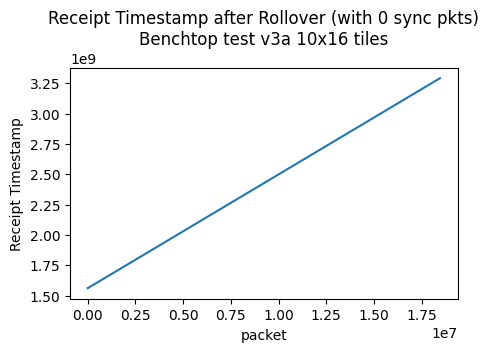

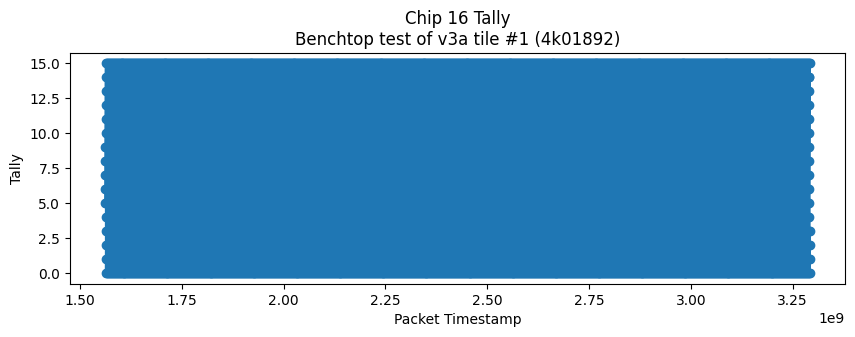

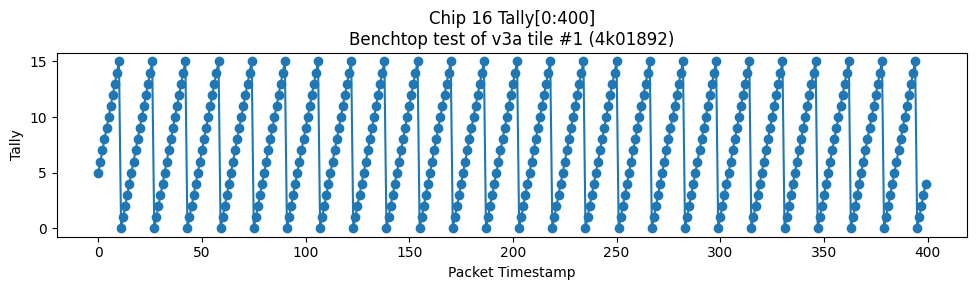

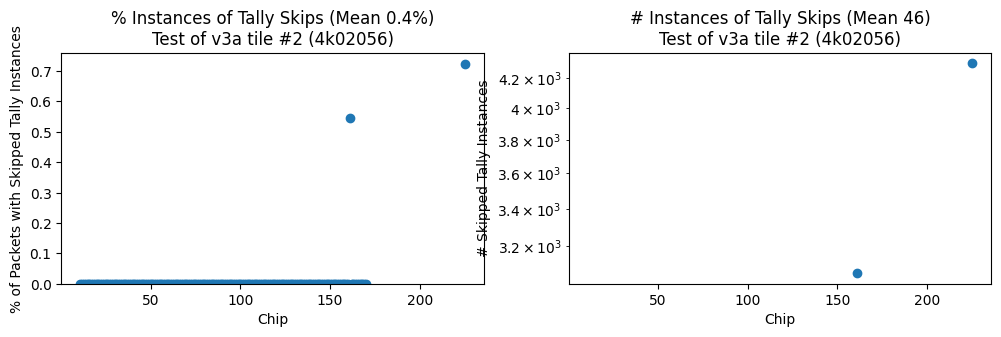

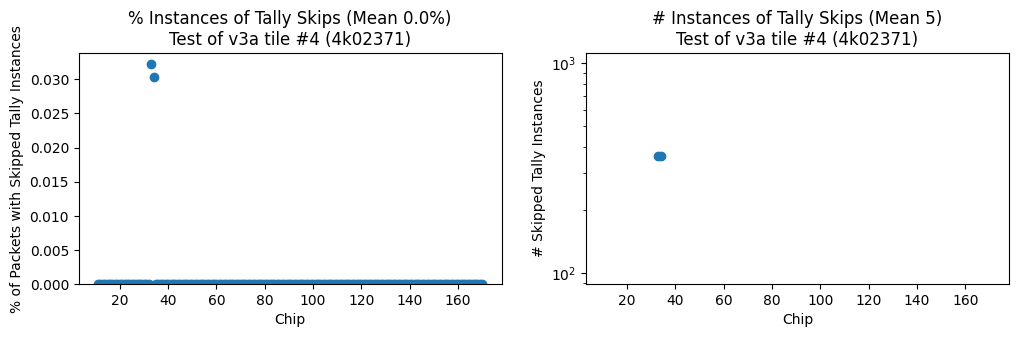

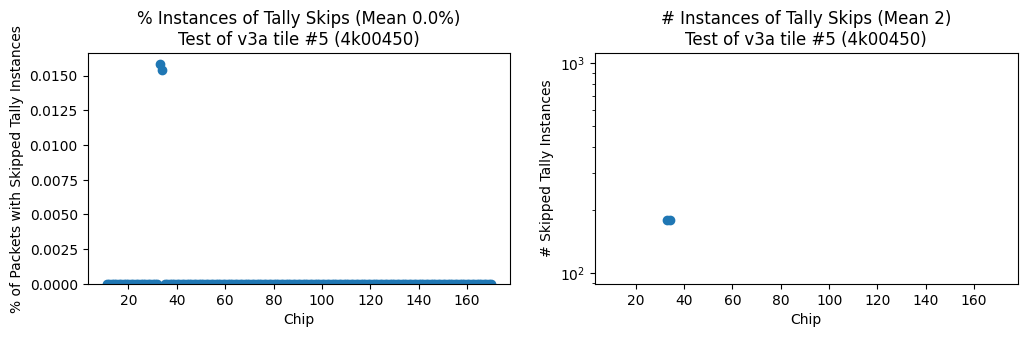

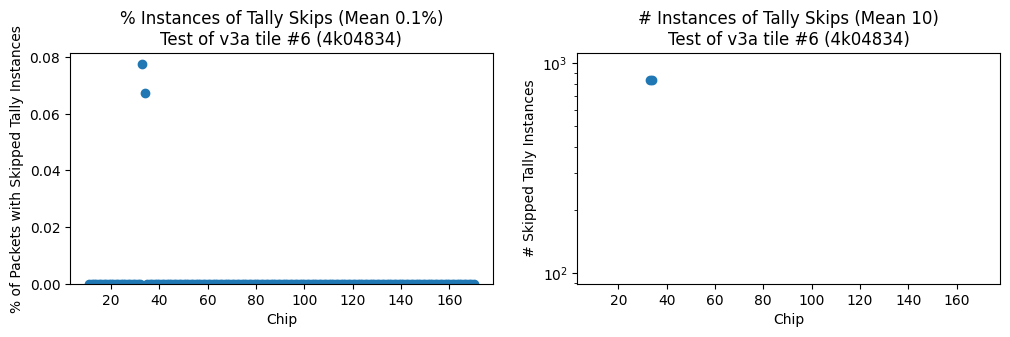

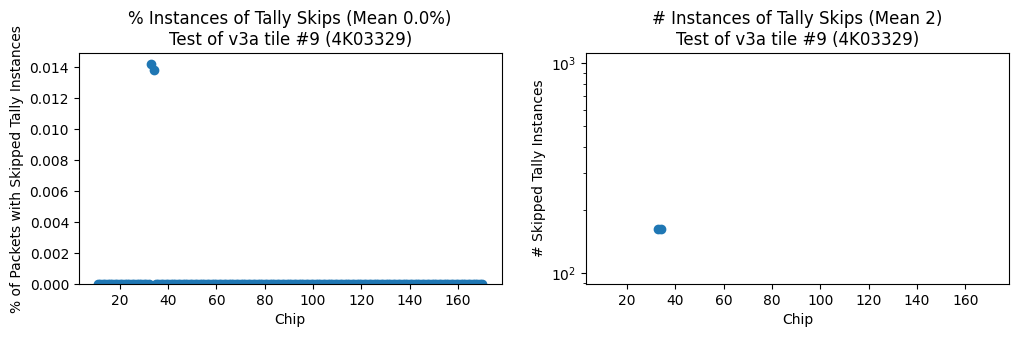

In [6]:
####################
# main
####################

get_data(filename)
